# Market Extremes Research

## Objective

Investigate whether the market exhibits mean reversion after becoming extremely overbought or oversold.

Research Questions:

- Do large market rallies lead to weaker future returns?
- Do large market declines lead to stronger future returns?
- Can market extremes be used to improve factor allocation?

Method:

- Build an equal-weight NIFTY500 market proxy.
- Measure distance from 252-day moving average.
- Analyze subsequent 42-day returns.
- Bucket observations into market stretch regimes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

print(close.shape)

(2716, 332)


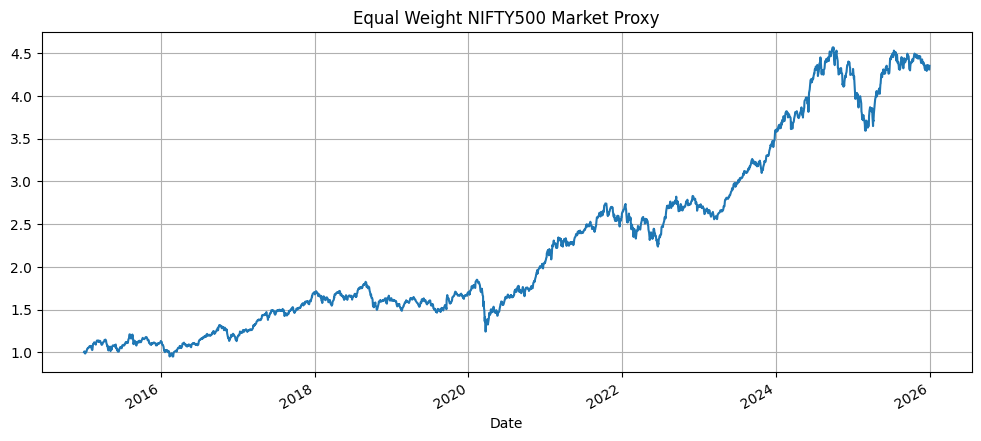

In [2]:
market = close.mean(axis=1)

market_index = (
    market
    /
    market.iloc[0]
)

market_index.plot(
    figsize=(12,5)
)

plt.title(
    "Equal Weight NIFTY500 Market Proxy"
)

plt.grid(True)

plt.show()

## Market Stretch Signal

Market Stretch is defined as:

Market Index / 252-Day Moving Average - 1

Interpretation:

- Positive values indicate overextended markets.
- Negative values indicate depressed markets.

In [3]:
ma252 = (
    market_index
    .rolling(252)
    .mean()
)

stretch = (
    market_index
    /
    ma252
    - 1
)

stretch.describe()

count    2465.000000
mean        0.072421
std         0.090961
min        -0.234475
25%         0.010294
50%         0.067737
75%         0.139654
max         0.324533
dtype: float64

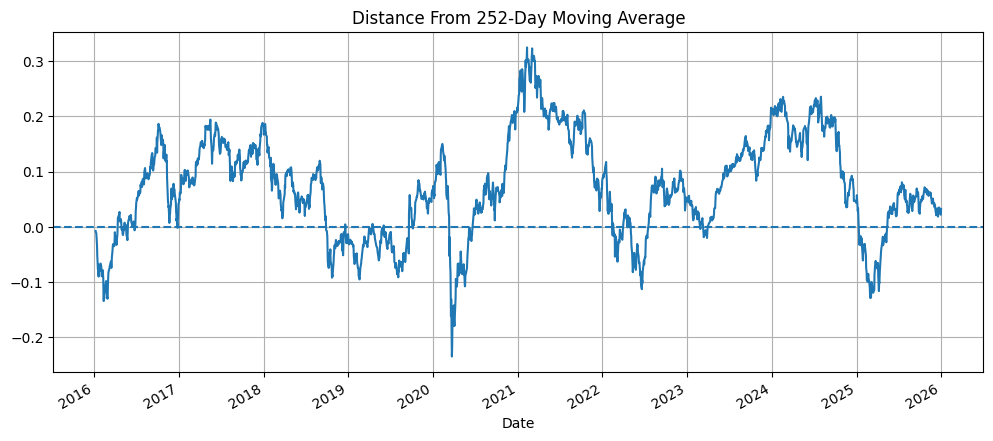

In [4]:
plt.figure(figsize=(12,5))

stretch.plot()

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Distance From 252-Day Moving Average"
)

plt.grid(True)

plt.savefig(
    "../results/plots/09_market_stretch.png",
    bbox_inches="tight"
)

plt.show()

In [5]:
future_return = (
    market_index
    .pct_change(42)
    .shift(-42)
)

df = pd.DataFrame({
    "Stretch":
        stretch,
    "FutureReturn":
        future_return
})

df = df.dropna()

df.head()

,Stretch,FutureReturn
Date,,
2016-01-08,-0.007361,-0.070816
2016-01-11,-0.012011,-0.064686
2016-01-12,-0.018666,-0.053988
2016-01-13,-0.025097,-0.055487
2016-01-14,-0.033200,-0.053002


In [6]:
correlation = (
    df["Stretch"]
    .corr(
        df["FutureReturn"]
    )
)

print(
    "Correlation:",
    round(correlation,4)
)

Correlation: -0.1587


## Mean Reversion Test

Observations are divided into five stretch buckets.

Objective:

Determine whether future market returns depend on current market extension.

In [7]:
df["Bucket"] = pd.qcut(
    df["Stretch"],
    5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

results = (
    df
    .groupby("Bucket")
    ["FutureReturn"]
    .agg(
        ["count","mean","std"]
    )
)

results["Sharpe"] = (
    results["mean"]
    /
    results["std"]
)

results.to_csv(
    "../results/tables/09_market_extremes.csv"
)

results

,count,mean,std,Sharpe
Bucket,,,,
Very Low,485,0.054021,0.068290,0.791059
Low,484,0.025681,0.063386,0.405160
Medium,485,0.015266,0.068578,0.222605
High,484,0.018814,0.087356,0.215370
Very High,485,0.027975,0.052344,0.534457


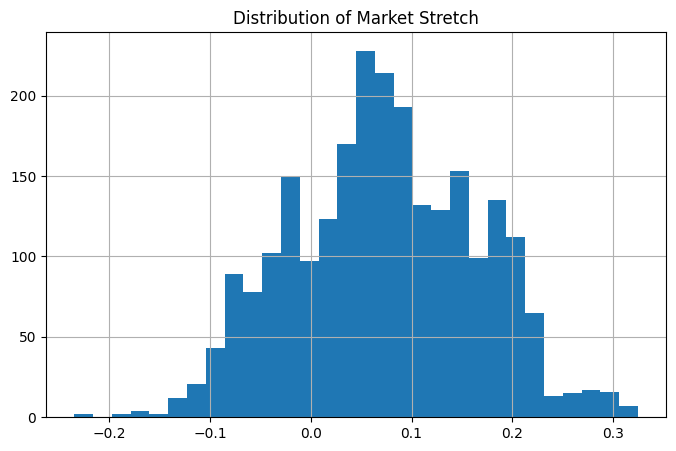

In [8]:
plt.figure(figsize=(8,5))

df["Stretch"].hist(
    bins=30
)

plt.title(
    "Distribution of Market Stretch"
)

plt.grid(True)

plt.savefig(
    "../results/plots/09_market_stretch_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Conclusion

Market Stretch exhibits mean-reverting characteristics.

Deeply oversold markets generated stronger future returns than normal market environments.

However, the signal did not improve the momentum strategy when incorporated into the portfolio allocation process.

The signal is informative but not additive to the existing momentum timing framework.